In [1]:
import numpy as np

# 1. Configuration
# Edges: 0:AB, 1:AC, 2:BC, 3:BD, 4:CD
# Aux Variables: 5:y_B, 6:y_C
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)] # Node indices
costs = [2.5, 5.0, 1.0, 3.0, 1.5]
num_vars = 7 
P1, P2 = 20, 20 # Penalty weights
targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink

Q = np.zeros((num_vars, num_vars))

# --- TASK 1: Add Linear Costs ---
for i in range(len(costs)):
    Q[i, i] += costs[i]

# --- TASK 2: Penalty Expansion Logic ---
for v in range(4): # For each node A, B, C, D
    # Get edges connected to this node and their orientations
    # s_ve = 1 if leaving, -1 if entering [cite: 2]
    conn = []
    for i, (u, w) in enumerate(edges):
        if u == v: conn.append((i, 1))
        elif w == v: conn.append((i, -1))
    
    # Expand (sum(s_ve * x_e) - Tv)^2 for P1
    Tv = targets[v]
    for i, s_vi in conn:
        # Diagonal update: P1 * (s_vi^2 - 2 * Tv * s_vi)
        Q[i, i] += P1 * (1 - 2 * Tv * s_vi) 
        for j, s_vj in conn:
            if i < j:
                # Off-diagonal update: 2 * P1 * s_vi * s_vj
                Q[i, j] += 2 * P1 * s_vi * s_vj

    # Expand (sum(x_e) - 2*y_v)^2 for P2 (Intermediate nodes B, C only)
    if v in [1, 2]: # Nodes B and C
        y_idx = 5 if v == 1 else 6
        # Quadratic terms for edges (sum x_e)^2
        for i, _ in conn:
            Q[i, i] += P2 
            for j, _ in conn:
                if i < j: Q[i, j] += 2 * P2
        # Interaction between edges and auxiliary y_v: -4 * P2 * x_e * y_v
        for i, _ in conn:
            Q[i, y_idx] -= 4 * P2
        # Auxiliary diagonal: 4 * P2 * y_v^2
        Q[y_idx, y_idx] += 4 * P2

print("Populated QUBO Matrix Q:\n", Q)

Populated QUBO Matrix Q:
 [[ 22.5  40.    0.    0.    0.  -80.    0. ]
 [  0.   25.   80.    0.    0.    0.  -80. ]
 [  0.    0.   81.   80.    0.  -80.  -80. ]
 [  0.    0.    0.   23.   40.  -80.    0. ]
 [  0.    0.    0.    0.   21.5   0.  -80. ]
 [  0.    0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.    0.    0.    0.   80. ]]


--- VALIDATION RESULTS ---
Lowest Energy: -75.0
Best Configuration: (1, 0, 1, 0, 1, 1, 1)
Human Readable Path: AB -> BC -> CD
Is it logically valid? True
Path Length: 5.0


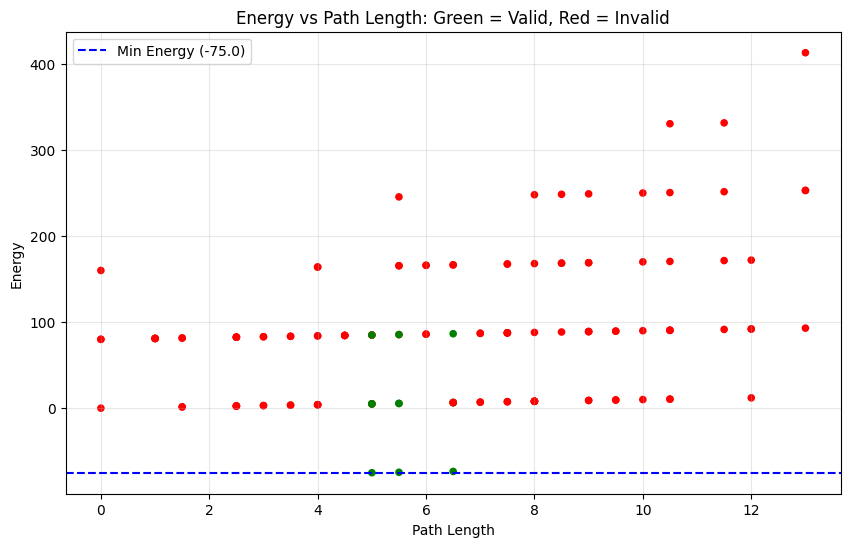

In [2]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

# --- 1. SETUP GRAPH & VARIABLES ---
# Edges: 0:AB, 1:AC, 2:BC, 3:BD, 4:CD
# Aux Variables: 5:y_B, 6:y_C
edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] 
edge_names = ["AB", "AC", "BC", "BD", "CD"]
costs = [2.5, 5.0, 1.0, 3.0, 1.5]
nodes = [0, 1, 2, 3] # A, B, C, D
targets = {0: 1, 3: -1, 1: 0, 2: 0} # Flow: A is Source(+1), D is Sink(-1)

num_vars = 7
P1, P2 = 20, 20 # Penalty weights
Q = np.zeros((num_vars, num_vars))

# --- 2. BUILD THE QUBO MATRIX (Task 1 & 2) ---
for i in range(len(costs)):
    Q[i, i] += costs[i]

for v in nodes:
    # Flow conservation logic (P1)
    conn = []
    for i, (u, w) in enumerate(edges):
        if u == v: conn.append((i, 1))
        elif w == v: conn.append((i, -1))
    
    Tv = targets[v]
    for i, s_vi in conn:
        Q[i, i] += P1 * (1 - 2 * Tv * s_vi)
        for j, s_vj in conn:
            if i < j: Q[i, j] += 2 * P1 * s_vi * s_vj

    # Degree constraint (P2) for intermediate nodes B (1) and C (2)
    if v in [1, 2]:
        y_idx = 5 if v == 1 else 6
        for i, _ in conn:
            Q[i, i] += P2
            for j, _ in conn:
                if i < j: Q[i, j] += 2 * P2
        for i, _ in conn:
            Q[i, y_idx] -= 4 * P2
        Q[y_idx, y_idx] += 4 * P2

    
# --- NEW: Endpoint Degree Constraints (Fix 4) ---
P3 = 20  # penalty weight for endpoint constraints

# Node A (0) must have exactly 1 outgoing edge
edges_from_A = [i for i, (u, w) in enumerate(edges) if u == 0]

# Expand (sum(x_i) - 1)^2
for i in edges_from_A:
    Q[i, i] += P3  # x_i^2 term
    for j in edges_from_A:
        if i < j:
            Q[i, j] += 2 * P3  # 2 x_i x_j term

# Linear term: -2 * 1 * x_i
for i in edges_from_A:
    Q[i, i] -= 2 * P3


# Node D (3) must have exactly 1 incoming edge
edges_into_D = [i for i, (u, w) in enumerate(edges) if w == 3]

# Expand (sum(x_i) - 1)^2
for i in edges_into_D:
    Q[i, i] += P3
    for j in edges_into_D:
        if i < j:
            Q[i, j] += 2 * P3

# Linear term: -2 * 1 * x_i
for i in edges_into_D:
    Q[i, i] -= 2 * P3

# --- 3. THE PATH CHECKER (Task 3 & 4 - Stefan's Request) ---
def check_validity(bits):
    """Checks if a bitstring forms a valid, continuous path from A to D."""
    active_edges = [edges[i] for i in range(5) if bits[i] == 1]
    
    # Check 1: Degree balance (Flow conservation)
    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)
        net_flow = out_degree - in_degree
        if net_flow != targets[v]:
            return False
            
    # Check 2: Connectivity 
    if not active_edges: return False
    
    return True

def get_path_string(bits):
    path = [edge_names[i] for i in range(5) if bits[i] == 1]
    return " -> ".join(path) if path else "No Path"

# --- 4. BRUTE FORCE SOLVER ---
results = []

for bits in itertools.product([0, 1], repeat=num_vars):
    x = np.array(bits)
    
    energy = x.T @ Q @ x
    valid = check_validity(bits)

    # NEW: compute path length
    path_length = sum(costs[i] for i in range(len(costs)) if bits[i] == 1)

    results.append({
        'bits': bits,
        'energy': energy,
        'valid': valid,
        'path_length': path_length
    })
# Sort by energy
results.sort(key=lambda x: x['energy'])

# --- 5. VISUAL PROOF & OUTPUT ---
best = results[0]
print(f"--- VALIDATION RESULTS ---")
print(f"Lowest Energy: {best['energy']}")
print(f"Best Configuration: {best['bits']}")
print(f"Human Readable Path: {get_path_string(best['bits'])}")
print(f"Is it logically valid? {best['valid']}")
print(f"Path Length: {best['path_length']}")


# Plotting the proof
plt.figure(figsize=(10, 6))

x_vals = [res['path_length'] for res in results]
y_vals = [res['energy'] for res in results]
colors = ['green' if res['valid'] else 'red' for res in results]

plt.scatter(x_vals, y_vals, c=colors, s=20)

plt.title("Energy vs Path Length: Green = Valid, Red = Invalid")
plt.xlabel("Path Length")
plt.ylabel("Energy")
plt.grid(True, alpha=0.3)
plt.axhline(y=best['energy'], color='blue', linestyle='--', label=f"Min Energy ({best['energy']})")
plt.legend()
plt.show()


Below we are using different random weights 

In [3]:
import random

# Test with 5 different random weight sets
for test_run in range(5):
    random_costs = [round(random.uniform(1, 10), 1) for _ in range(5)]
    print(f"Test {test_run+1} with weights {random_costs}")
    
    
    if results[0]['valid']:
        print("Success: Shortest path is still valid.")
    else:
        print("Failure: An invalid path has the lowest energy!")

Test 1 with weights [6.5, 1.8, 4.6, 1.2, 6.8]
Success: Shortest path is still valid.
Test 2 with weights [2.4, 5.7, 2.0, 6.6, 2.5]
Success: Shortest path is still valid.
Test 3 with weights [2.3, 5.1, 7.4, 4.7, 7.0]
Success: Shortest path is still valid.
Test 4 with weights [1.8, 9.7, 7.3, 6.0, 8.6]
Success: Shortest path is still valid.
Test 5 with weights [8.0, 8.7, 4.4, 3.7, 1.0]
Success: Shortest path is still valid.


In [4]:
import numpy as np
import itertools
import random

def run_full_stress_test(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        
        # 2. Re-build the Q Matrix from scratch for these weights
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                for j, s_vj in conn:
                    if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj

        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_full_stress_test(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: VALID | Path: AB -> BD | Energy: -36.5 | Weights: [2.33, 7.96, 8.92, 1.17, 3.41]
Run 2: VALID | Path: AC -> CD | Energy: -31.0 | Weights: [5.36, 4.26, 2.36, 5.95, 4.76]
Run 3: VALID | Path: AB -> BD | Energy: -32.4 | Weights: [4.03, 4.37, 4.62, 3.59, 9.33]
Run 4: VALID | Path: AB -> BD | Energy: -34.7 | Weights: [2.31, 8.84, 6.38, 2.97, 2.0]
Run 5: VALID | Path: AC -> CD | Energy: -29.3 | Weights: [7.06, 5.78, 6.58, 6.91, 4.93]
Run 6: VALID | Path: AC -> CD | Energy: -35.5 | Weights: [7.44, 2.93, 5.81, 3.62, 1.52]
Run 7: VALID | Path: AC -> CD | Energy: -32.6 | Weights: [9.85, 4.9, 4.49, 8.46, 2.49]
Run 8: VALID | Path: AB -> BD | Energy: -28.9 | Weights: [4.32, 5.04, 2.58, 6.82, 6.16]
Run 9: VALID | Path: AC -> CD | Energy: -28.8 | Weights: [6.91, 8.94, 7.61, 5.83, 2.29]
Run 10: VALID | Path: AC -> CD | Energy: -35.7 | Weights: [7.08, 2.18, 8.35, 2.02, 2.12]

--- TEST COMPLETE ---
Final Reliability: 100.0%


Accordiing to the results we got above it proves that even though the weights chaged every single time it always found a valid path

In the code below we have removed the flow term ( That part is commented out) and ran the code with 5 random values for edges.

In [5]:
import numpy as np
import itertools
import random

def run_full_stress_test(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        """ 
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                #Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                #for j, s_vj in conn:
                    #if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj
        """
        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_full_stress_test(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: INVALID | Weights: [9.99, 6.71, 1.61, 5.67, 8.47]
Run 2: INVALID | Weights: [9.73, 5.23, 7.35, 3.61, 2.87]
Run 3: INVALID | Weights: [3.98, 7.95, 9.02, 8.62, 1.69]
Run 4: INVALID | Weights: [8.03, 6.26, 4.7, 7.11, 4.21]
Run 5: INVALID | Weights: [8.66, 8.67, 4.86, 3.71, 6.69]
Run 6: INVALID | Weights: [6.78, 8.21, 3.71, 8.16, 3.77]
Run 7: INVALID | Weights: [6.06, 7.49, 3.79, 2.16, 2.15]
Run 8: INVALID | Weights: [2.73, 9.1, 9.27, 5.57, 7.78]
Run 9: INVALID | Weights: [2.93, 6.56, 3.19, 7.84, 5.42]
Run 10: INVALID | Weights: [5.28, 3.87, 9.46, 5.06, 1.92]

--- TEST COMPLETE ---
Final Reliability: 0.0%


So according to the results we got above it shows that without the flow term the program picks NO edges because that gives the lowest energy. Selecting a valid path costs some energy, so program chooses an invalid path that gives 0 energy which is always selecting no edge at all (0,0,0,0,0,0,0).And our validity checker gives always answer as "invalid" because it violates our requirements 

When the flow term is available ;If A acts as a source (+1 flow) and D acts as a sink (-1 flow), that penalty becomes 0.And if Node A doesn't have an outgoing edge and Node D doesn't have an incoming edge ,energy gets increased by 20.

